# Bvarta Bahari — 01. Pemahaman Bisnis & Data

Notebook ini fokus pada pemahaman bisnis dan audit kualitas data sebelum masuk ke pemodelan.
Tujuannya memastikan struktur data benar-benar dipahami dan tahu di mana letak masalahnya,
supaya pilihan model nanti berdasar bukti.

Yang dikerjakan:
1. Konfirmasi struktur dan tipe seluruh tabel langsung dari data.
2. Audit kualitas: pola nilai hilang, hubungan `trips=0` vs `cancelled`, frekuensi pembatalan.
3. Cek perbedaan format tanggal di `weather_wind_wave` dan konsistensi join antar tabel.
4. Diagnostik sinyal awal untuk kandidat target forecast (STL, ACF/PACF).
5. Kesimpulan: apakah data cukup sehat untuk demand forecast dan apa risikonya.

Fakta yang terbaca dari data dibedakan dari asumsi (ditandai eksplisit). Periode data
1 Jun 2022 – 31 Mei 2025 (3 tahun); mata uang IDR; jarak dalam nautical mile.

In [1]:
import warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

DATA = "../data/"   # data/ read-only
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
RNG = np.random.default_rng(42)
plt.rcParams["figure.figsize"] = (11, 3.4)
print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.3 | numpy 2.4.6


## 1. Load semua tabel & konfirmasi struktur

In [2]:
# Load semua tabel langsung dgn read_csv. Catatan format tanggal:
#  - orders/calendar/rainfall/mobility: date YYYY-MM-DD -> parse_dates
#  - wind_wave: date DD/MM/YYYY (beda format!) -> parse manual di bawah
#  - tides: datetime tz-aware (UTC+7) -> parse manual saat dipakai (sel. 4)
tables = {
    "ports":         pd.read_csv(DATA+"ports.csv"),
    "fleet":         pd.read_csv(DATA+"fleet.csv"),
    "routes":        pd.read_csv(DATA+"routes_existing.csv"),
    "prices":        pd.read_csv(DATA+"route_prices.csv"),
    "orders":        pd.read_csv(DATA+"orders_history_daily.csv", parse_dates=["date"]),
    "calendar":      pd.read_csv(DATA+"calendar_events.csv", parse_dates=["date"]),
    "opex":          pd.read_csv(DATA+"route_opex_monthly.csv"),
    "tide_stations": pd.read_csv(DATA+"tide_stations.csv"),
    "wind_wave":     pd.read_csv(DATA+"weather_wind_wave_daily.csv"),
    "rainfall":      pd.read_csv(DATA+"weather_rainfall_daily.csv", parse_dates=["date"]),
}
tables["wind_wave"]["date"] = pd.to_datetime(tables["wind_wave"]["date"], format="%d/%m/%Y")

overview = pd.DataFrame({
    "rows": {k: len(v) for k, v in tables.items()},
    "cols": {k: v.shape[1] for k, v in tables.items()},
}).join(pd.Series({k: ", ".join(v.columns) for k, v in tables.items()}, name="columns"))
overview

,rows,cols,columns
ports,19,10,"port_id, port_name, island, province, region, ..."
fleet,35,13,"ship_id, ship_name, ship_type, year_built, pax..."
routes,16,8,"route_id, origin_port_id, dest_port_id, route_..."
prices,42,3,"route_id, ticket_class, price_idr"
orders,17536,7,"date, route_id, trips, seats_available, ticket..."
calendar,251,3,"date, event_name, event_type"
opex,576,7,"route_id, month, fuel_cost_idr, crew_cost_idr,..."
tide_stations,19,9,"station_id, port_id, port_name, lat, lon, sea_..."
wind_wave,7672,4,"date, sea_area, wind_speed_knots, wave_height_m"
rainfall,12056,3,"date, region, rainfall_mm"


**Catatan domain:**
- `routes`: 16 rute, terdiri dari 3 rute `wajib` (R01–R03, tak boleh dihapus) + 13 `rancangan`.
- `fleet`: 35 kapal, 4 tipe; punya `draft_m`, `max_operating_wave_m`, `status` sebagai batasan fisik.
- `ports`: 19 pelabuhan; `sea_area` (ke data cuaca laut) & `region` (ke hujan/mobilitas) jadi kunci jembatan.

In [3]:
rt = tables["routes"]
display(rt.assign().sort_values("route_type"))
print("route_type:", rt.route_type.value_counts().to_dict())
print("fleet status:", tables["fleet"].status.value_counts().to_dict())
print("ship_type:", tables["fleet"].ship_type.value_counts().to_dict())

,route_id,origin_port_id,dest_port_id,route_type,assigned_ship_id,frequency_per_week,distance_nm,scheduled_duration_hr
3,R04,PRK,SMG,rancangan,KM-09,7,277.2,19.6
4,R05,SMG,SBY,rancangan,KM-23,7,155.3,6.2
5,R06,PRK,SBY,rancangan,KM-20,5,494.7,36.7
6,R07,SBY,BNO,rancangan,KM-16,6,208.6,17.8
7,R08,CBN,SMG,rancangan,KM-35,4,147.3,14.7
8,R09,PJG,BBR,rancangan,KM-06,3,202.5,13.8
9,R10,BBR,BTM,rancangan,KM-08,3,313.7,18.7
10,R11,BTM,TPI,rancangan,KM-10,21,40.2,3.5
11,R12,DMI,BTM,rancangan,KM-12,4,199.0,9.4
12,R13,BLW,BTM,rancangan,KM-14,2,426.9,16.5


route_type: {'rancangan': 13, 'wajib': 3}
fleet status: {'active': 34, 'maintenance': 1}
ship_type: {'RoRo Ferry': 16, 'Passenger Ship': 10, 'Fast Ferry': 5, 'Cargo/RoPax': 4}


## 2. Audit kualitas: `orders_history_daily`

Ini sumber target forecast, jadi diaudit paling detail.

In [4]:
o = tables["orders"]
span = (o.date.max() - o.date.min()).days + 1
print(f"range {o.date.min().date()} .. {o.date.max().date()} | span={span} hari | "
      f"routes={o.route_id.nunique()} | rows={len(o)} (=16x1096 panel lengkap: {len(o)==16*span})")
print("\nMissing per kolom:")
print(o.isna().sum().to_string())

range 2022-06-01 .. 2025-05-31 | span=1096 hari | routes=16 | rows=17536 (=16x1096 panel lengkap: True)

Missing per kolom:
date                 0
route_id             0
trips                0
seats_available      0
tickets_sold       167
load_factor        167
cancelled            0


### 2a. Pola nilai hilang `tickets_sold` / `load_factor`
Menurut kamus data, nilai hilang berasal dari downtime sistem. Kita cek apakah nilai hilang
hanya muncul di hari berlayar (`trips>0`). Kalau ya, sifatnya acak (bisa diimputasi/diabaikan),
bukan masalah struktural.

In [5]:
miss = o.load_factor.isna()
print("Total missing load_factor:", miss.sum(), f"({miss.mean():.2%})")
print("  di hari trips>0 :", (miss & (o.trips>0)).sum())
print("  di hari trips==0:", (miss & (o.trips==0)).sum())
print("\nDi hari trips==0 -> tickets_sold & load_factor selalu 0 (structural zero, BUKAN missing):")
z = o[o.trips==0]
print("  frac tickets_sold==0:", (z.tickets_sold==0).mean(), "| frac load_factor==0:", (z.load_factor==0).mean())
print("Missing rate pada hari berlayar (trips>0):", o.loc[o.trips>0, 'load_factor'].isna().mean().round(4))

Total missing load_factor: 167 (0.95%)
  di hari trips>0 : 167
  di hari trips==0: 0

Di hari trips==0 -> tickets_sold & load_factor selalu 0 (structural zero, BUKAN missing):
  frac tickets_sold==0: 1.0 | frac load_factor==0: 1.0
Missing rate pada hari berlayar (trips>0): 0.0161


### 2b. `trips=0` & `cancelled` — hari tanpa pelayaran
`trips=0` berarti tidak berlayar, bukan nilai hilang. Penyebabnya ada dua: dibatalkan
(`cancelled=1`, mis. cuaca/hari khusus) atau memang tidak terjadwal hari itu (frekuensi kurang
dari harian). Bedanya penting untuk mendefinisikan target.

In [6]:
print("cancelled=1 & trips>0 :", ((o.cancelled==1)&(o.trips>0)).sum(), "(harusnya 0: batal => tak berlayar)")
print("cancelled=1 & trips==0:", ((o.cancelled==1)&(o.trips==0)).sum(), "(pembatalan)")
print("cancelled=0 & trips==0:", ((o.cancelled==0)&(o.trips==0)).sum(), "(non-sailing terjadwal)")
print("\nOverall: trips==0 =", f"{(o.trips==0).mean():.1%}", "| cancelled=1 =", f"{o.cancelled.mean():.1%}")

cancelled=1 & trips>0 : 0 (harusnya 0: batal => tak berlayar)
cancelled=1 & trips==0: 3535 (pembatalan)
cancelled=0 & trips==0: 3607 (non-sailing terjadwal)

Overall: trips==0 = 40.7% | cancelled=1 = 20.2%


### 2c. Ringkasan kualitas & karakter permintaan per rute

In [7]:
per_route = o.groupby("route_id").agg(
    sail_frac=("trips", lambda s: (s>0).mean()),
    cancel_frac=("cancelled", "mean"),
    lf_mean_sailing=("load_factor", lambda s: s[s>0].mean()),
    tick_miss=("tickets_sold", lambda s: int(s.isna().sum())),
    seats_mean=("seats_available", "mean"),
).round(3)
per_route = per_route.merge(rt.set_index("route_id")[["route_type","frequency_per_week","distance_nm"]],
                            left_index=True, right_index=True)
per_route.sort_values("sail_frac", ascending=False)

,sail_frac,cancel_frac,lf_mean_sailing,tick_miss,seats_mean,route_type,frequency_per_week,distance_nm
route_id,,,,,,,,
R04,0.995,0.005,0.786,16,1130.776,rancangan,7,277.2
R11,0.988,0.012,0.869,19,2303.351,rancangan,21,40.2
R01,0.985,0.015,0.896,22,14402.628,wajib,84,18.3
R02,0.948,0.052,0.917,16,2216.407,wajib,96,4.2
R03,0.821,0.179,0.311,13,596.168,wajib,14,31.5
R07,0.693,0.208,0.720,16,414.672,rancangan,6,208.6
R06,0.595,0.161,0.642,12,343.847,rancangan,5,494.7
R15,0.526,0.252,0.291,4,246.383,rancangan,5,87.7
R08,0.490,0.161,0.573,4,197.945,rancangan,4,147.3


**Pembacaan:**
- Rute padat & hampir harian: R01, R02, R04, R11 (`sail_frac` 0.93–0.99, `lf_mean_sailing`
  0.78–0.92). Serinya rapat dan sinyalnya kuat, jadi kandidat utama forecast.
- Rute intermiten / sering batal: R12–R14 (`cancel_frac` ~0.47, `sail_frac` < 0.32),
  permintaannya mayoritas nol, jadi forecast harian langsung rapuh.
- Untuk rute dengan `sail_frac == 1 - cancel_frac` (R01–R05, R11), setiap hari tanpa pelayaran
  berarti pembatalan (dijadwalkan tiap hari). Sisanya berjadwal kurang dari harian.

## 3. Format tanggal & konsistensi join

In [8]:
ww = tables["wind_wave"]   # date DD/MM/YYYY sudah diparse di sel. load
print("wind_wave (DD/MM/YYYY) -> range:", ww.date.min().date(), "..", ww.date.max().date(),
      "| sama dgn orders:", (ww.date.min()==o.date.min()) and (ww.date.max()==o.date.max()))

p = tables["ports"]; rf = tables["rainfall"]
mob = pd.read_csv(DATA+"mobility_daily.csv", parse_dates=["date"])
print()
print("Konsistensi kunci join (himpunan harus cocok):")
print("  sea_area  ports vs wind_wave   diff:", set(p.sea_area) ^ set(ww.sea_area))
print("  region    ports vs rainfall    diff:", set(p.region) ^ set(rf.region))
print("  port_id   ports vs tide_stat   diff:", set(p.port_id) ^ set(tables['tide_stations'].port_id))
print("  region    ports vs mobility    diff:", set(p.region) ^ (set(mob.origin_region)|set(mob.dest_region)))
print("  route portids ada di ports     :", set(rt.origin_port_id)|set(rt.dest_port_id) <= set(p.port_id))

wind_wave (DD/MM/YYYY) -> range: 2022-06-01 .. 2025-05-31 | sama dgn orders: True



Konsistensi kunci join (himpunan harus cocok):
  sea_area  ports vs wind_wave   diff: set()
  region    ports vs rainfall    diff: set()
  port_id   ports vs tide_stat   diff: set()
  region    ports vs mobility    diff: set()
  route portids ada di ports     : True


Semua himpunan kunci cocok (`diff` kosong), jadi join `region` / `sea_area` / `port` aman
dengan `ports` sebagai jembatan. Tanggal `wind_wave` benar setelah diparse dari format `DD/MM/YYYY`.

## 4. `tides_hourly` — ringkasan

File besar (~500k baris), dibaca lewat pandas lalu diringkas, bukan ditampilkan utuh.

In [9]:
# tides ~500k baris: baca via pandas lalu ringkas (jangan dump utuh). datetime tz-aware UTC+7.
td = pd.read_csv(DATA+"tides_hourly.csv")
td["datetime"] = pd.to_datetime(td["datetime"], utc=True)
print("shape", td.shape, "| ports", td.port_id.nunique(), "| range",
      td.datetime.min(), "->", td.datetime.max())
print("rows/port =", td.shape[0]//td.port_id.nunique(), "(expected 1096*24 =", 1096*24, ")")
print("water_level_m missing:", f"{td.water_level_m.isna().mean():.3%}", "(gap sensor)")
display(td.water_level_m.describe().round(3).to_frame().T)

shape (499776, 3) | ports 19 | range 2022-05-31 17:00:00+00:00 -> 2025-05-31 16:00:00+00:00
rows/port = 26304 (expected 1096*24 = 26304 )
water_level_m missing: 0.817% (gap sensor)


,count,mean,std,min,25%,50%,75%,max
water_level_m,495693.0,2.01,0.634,-0.421,1.58,2.0,2.434,4.586


## 5. Diagnostik sinyal target — STL & ACF/PACF

Target kandidat adalah `load_factor` harian. Dekomposisi butuh seri yang reguler, jadi hari
tanpa pelayaran (nilai 0) di-mask jadi NaN lalu diinterpolasi hanya untuk keperluan visual EDA,
bukan untuk modeling. Kita bandingkan rute kuat (R01) dengan rute intermiten (R09).

In [10]:
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def prep(rid):
    s = o[o.route_id==rid].set_index("date").sort_index()["load_factor"].asfreq("D")
    return s.replace(0, np.nan).interpolate(limit_direction="both")

def diag(rid):
    s = prep(rid).dropna()
    adf_p = adfuller(s)[1]
    try: kpss_p = kpss(s, regression="c", nlags="auto")[1]
    except Exception: kpss_p = np.nan
    stl = STL(s, period=7, robust=True).fit()
    F_s = max(0, 1 - stl.resid.var()/(stl.resid+stl.seasonal).var())
    F_t = max(0, 1 - stl.resid.var()/(stl.resid+stl.trend).var())
    return dict(route=rid, n=len(s), ADF_p=round(adf_p,4), KPSS_p=round(kpss_p,4),
                seas_str=round(F_s,2), trend_str=round(F_t,2)), stl

rows=[]; stls={}
for rid in ["R01","R02","R11","R04","R09","R13"]:
    r,stl = diag(rid); rows.append(r); stls[rid]=stl
pd.DataFrame(rows).set_index("route")

C:\Users\novia\AppData\Local\Temp\ipykernel_6452\1455661330.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  try: kpss_p = kpss(s, regression="c", nlags="auto")[1]


C:\Users\novia\AppData\Local\Temp\ipykernel_6452\1455661330.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  try: kpss_p = kpss(s, regression="c", nlags="auto")[1]


C:\Users\novia\AppData\Local\Temp\ipykernel_6452\1455661330.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  try: kpss_p = kpss(s, regression="c", nlags="auto")[1]


C:\Users\novia\AppData\Local\Temp\ipykernel_6452\1455661330.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  try: kpss_p = kpss(s, regression="c", nlags="auto")[1]


C:\Users\novia\AppData\Local\Temp\ipykernel_6452\1455661330.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  try: kpss_p = kpss(s, regression="c", nlags="auto")[1]


C:\Users\novia\AppData\Local\Temp\ipykernel_6452\1455661330.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  try: kpss_p = kpss(s, regression="c", nlags="auto")[1]


,n,ADF_p,KPSS_p,seas_str,trend_str
route,,,,,
R01,1096,0.0003,0.10,0.45,0.43
R02,1096,0.0004,0.10,0.36,0.33
R11,1096,0.0010,0.10,0.50,0.45
R04,1096,0.0001,0.10,0.57,0.55
R09,1096,0.0000,0.10,0.14,0.69
R13,1096,0.0461,0.01,0.03,0.86


ADF p<0.05 di semua seri, jadi tidak ada unit root kuat (level stasioner). Kekuatan musiman
mingguan STL (`seas_str`) tinggi pada rute padat (R01/R11 ≈0.45–0.50) dan rendah pada rute
intermiten (R09/R13), di mana sinyalnya lebih ditentukan struktur nol ketimbang musim.

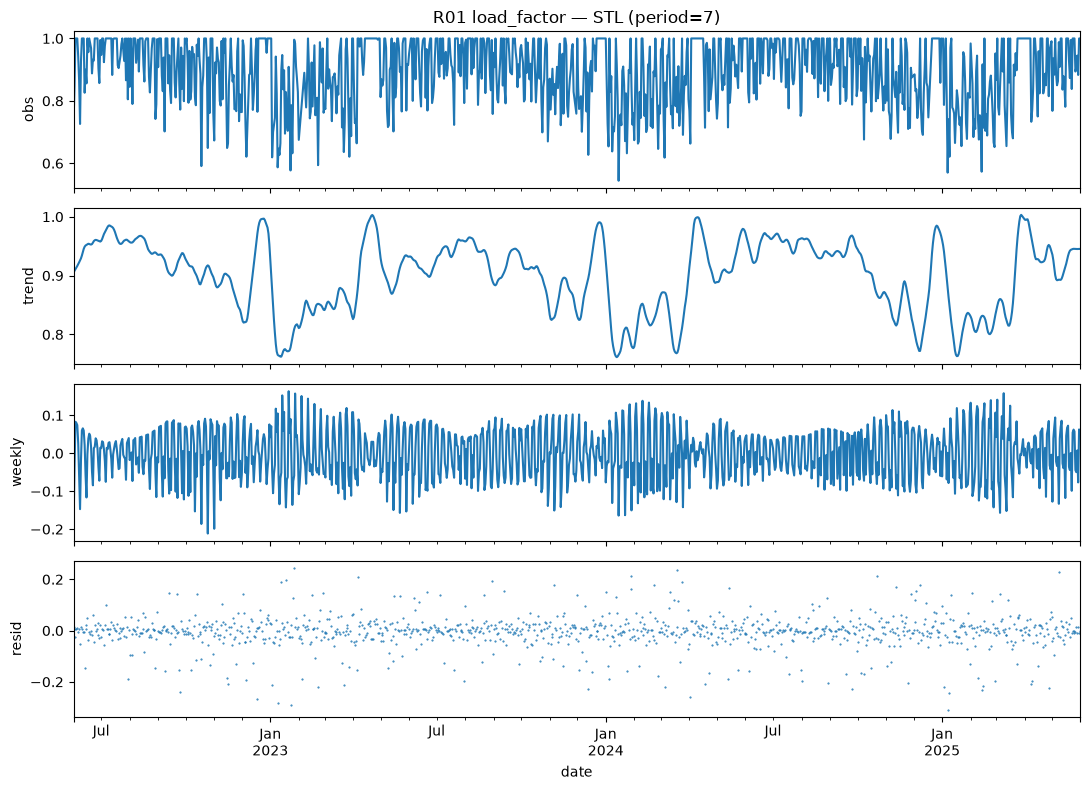

In [11]:
rid="R01"; stl=stls[rid]
fig,ax=plt.subplots(4,1,figsize=(11,8),sharex=True)
stl.observed.plot(ax=ax[0],title=f"{rid} load_factor — STL (period=7)"); ax[0].set_ylabel("obs")
stl.trend.plot(ax=ax[1]); ax[1].set_ylabel("trend")
stl.seasonal.plot(ax=ax[2]); ax[2].set_ylabel("weekly")
stl.resid.plot(ax=ax[3],marker=".",lw=0,ms=1); ax[3].set_ylabel("resid")
plt.tight_layout(); plt.show()

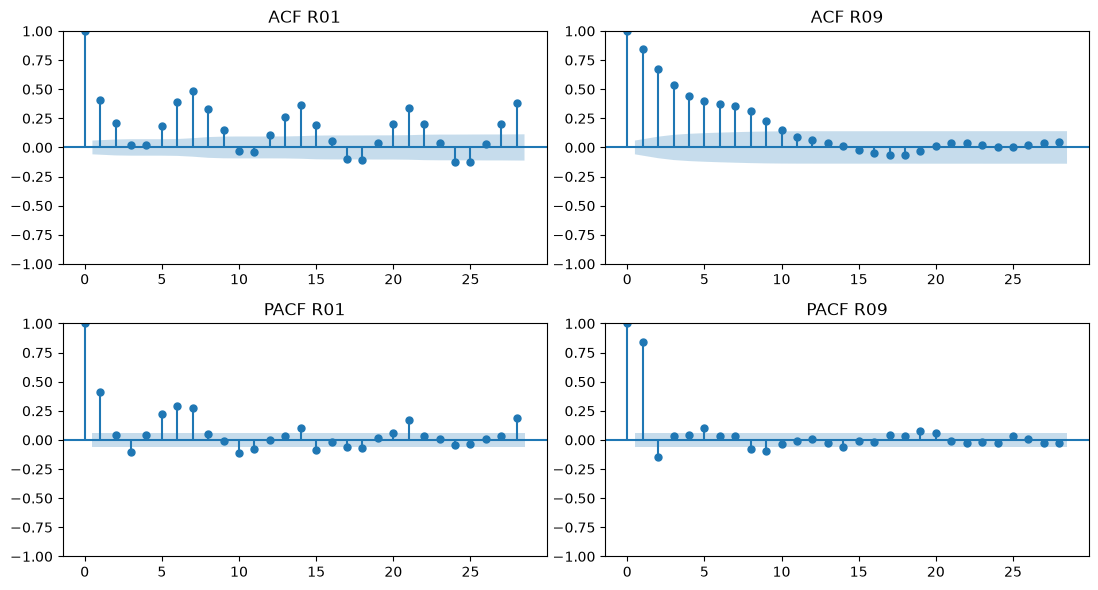

In [12]:
fig,ax=plt.subplots(2,2,figsize=(11,6))
for j,rid in enumerate(["R01","R09"]):
    s=prep(rid).dropna()
    plot_acf(s,lags=28,ax=ax[0,j],title=f"ACF {rid}")
    plot_pacf(s,lags=28,ax=ax[1,j],method="ywm",title=f"PACF {rid}")
plt.tight_layout(); plt.show()

ACF R01 memuncak pada lag 7/14/21 (musiman mingguan jelas) dan PACF terpotong cepat,
menandakan struktur AR + musim mingguan (cocok untuk ARIMA musiman atau fitur kalender). Pada
R09, ACF luruh lambat sebagian karena artefak interpolasi pada seri jarang, menegaskan rute
intermiten tidak cocok untuk forecast harian per titik.

## 6. Pengaruh kalender (variabel eksogen)

In [13]:
cal = tables["calendar"]
hol = set(cal.date.dt.normalize())
o2 = o.copy(); o2["is_event"] = o2.date.isin(hol)
chk = o2[o2.route_id.isin(["R01","R02","R11"]) & (o2.trips>0)].groupby("is_event").agg(
    lf_mean=("load_factor","mean"), cancel_rate=("cancelled","mean"), n=("date","size")).round(3)
print("Rute padat — load_factor & cancel rate: hari biasa vs hari event")
display(chk)
print("event_type:", cal.event_type.value_counts().to_dict())

Rute padat — load_factor & cancel rate: hari biasa vs hari event


,lf_mean,cancel_rate,n
is_event,,,
False,0.883,0.0,2472
True,0.930,0.0,730


event_type: {'school_holiday': 117, 'religious': 96, 'national_holiday': 38}


## 7. Ringkasan Temuan & Kesimpulan Awal

**Kondisi data:**
1. Panel harian lengkap: 16 rute × 1096 hari (2022-06-01..2025-05-31), tanpa baris hilang.
2. Nilai hilang `tickets_sold`/`load_factor` tipis (~0.95%) dan hanya muncul di hari berlayar
   (`trips>0`), konsisten dengan downtime sistem dan mudah ditangani. Di hari tanpa pelayaran
   keduanya bernilai 0 secara struktural (bukan nilai hilang).
3. `trips=0` (40.7%) terdiri dari pembatalan (`cancelled=1`, 20.2%) + non-sailing terjadwal
   (20.5%). `cancelled=1` selalu disertai `trips=0` (konsisten).
4. Heterogenitas antar rute tinggi: rute padat (R01/R02/R04/R11, sail_frac 0.93–0.99, LF
   0.78–0.92) vs intermiten/sering-batal (R12–R14, cancel ~0.47, mayoritas nol).
5. Join bersih di ketiga level (region/sea_area/port); tanggal `wind_wave` `DD/MM/YYYY`
   terverifikasi. Tides 19 port per jam lengkap (gap 0.8%), basis kuat untuk model pasut.
6. Sinyal temporal: rute padat stasioner (ADF p<0.01) dengan musiman mingguan jelas (ACF lag
   7/14, STL seas_str ~0.45–0.50); event kalender menggeser LF/cancel, jadi layak jadi eksogen.

**Kesimpulan: apakah data cukup sehat untuk demand forecast? Ya, dengan cakupan yang terarah.**
- Layak dan defensible: forecast permintaan (LF / tickets_sold) pada rute padat (R01, R02, R04,
  R11). Seri panjang (3 tahun), sinyal mingguan + musiman tahunan + eksogen kalender/cuaca.
  Backtest temporal jelas (mis. latih 2 tahun, uji 1 tahun). Ini kandidat model utama.
- Rapuh / butuh pendekatan beda: rute intermiten R12–R16, permintaan jarang & sering batal,
  forecast harian per titik tidak tepat. Lebih tepat ditangani sebagai intermittent demand
  (agregasi mingguan / model hurdle) atau dialihkan ke keputusan frekuensi.
- Pendukung kuat dan independen: prediksi pasut dari `tides_hourly` untuk jendela layar aman,
  datanya padat & periodik dengan validasi train/test lintas tahun yang bersih.

**Risiko utama yang harus dijaga saat pemodelan:**
- Definisi target bisa bocor: mencampur nol struktural (non-sailing/cancel) dengan permintaan
  riil akan membiaskan model. Perlu memisahkan kejadian berlayar/tidak dari intensitas (LF saat berlayar).
- Endogenitas pembatalan: `cancelled` dipicu cuaca/event, jadi LF hanya teramati pada hari yang
  "selamat" (ada efek seleksi). Forecast LF harus eksplisit kondisional "diberikan berlayar".
- Cuaca vs tides sebagai fitur: cuaca harian hanya per `sea_area` (kasar), tides per jam (halus),
  beda granularitas, hati-hati saat dijadikan regressor.
- Heterogenitas rute: model per-rute vs global pooled, ada trade-off karena data tipis di rute intermiten.